<div style="font-family:monospace; 
            border-radius:10px; 
            border:#f77f00 solid; 
            padding: 20px; 
            background-color: #caf0f8; 
            font-size:100%; 
            text-align: right">

<h1 align="left"><font color='#000000'>SDSC2001 Tutorial 12: Machine Learning Project Example</font></h1>
    
In this tutorial we will go through a simple pipeline for developing and testing machine learning models. Our task will be to predict whether someone has diabetes or not from health data. 

**TA: Collin Sakal**

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 200%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >Basic Machine Leaning Terminology</p>

| Term | Meaning | Extra Notes| 
| :--- | :--- | :--- |
|Feature(s)| Variable or variables your model will use to predict something||
|Feature matrix|All features (often stored in a numpy array or data frame) your model uses to make predictions|In sklearn the feature matrix is often refered to as ```X```. People will often use ```X_train``` to denote the feature matrix for the training data and ```X_test``` for the test data |
|Target|  Variable you model is trying to predict| Sometimes also referred to as the "Label" or "Ground Truth"|
|Classification|When we want to predict a target with classes|Classes are usually finite or categorical such as cats versus dogs, diabetes versus no diabetes, etc|
|Regression|When our target is numeric|Regression tasks include predicting stock prices, GPA, etc|
|Training data|Data used to develop your model||
|Testing data| Data used to evaluate your model on unseen data| You may encounter the phrase "validation data" which can **sometimes** mean the same thing as test data|
|Hyperparameters|Model "settings" you can adjust to try and improve the model's performance||

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 200%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >Model Evaluation Metrics</p>
          
In order to evaluate the effectiveness of our models we need to select a metric that quantifies the model's performance. Note that sometimes it is useful to evaluate your model based on multiple metrics. Evaluation metrics also differ based on the type of machine learning task. 

**Common metrics for binary classification:** <br>
- Accuracy <br>
- Sensitivity <br>
- Specificity <br>
- Recall <br>
- Precision <br>
- F1 score
- Area Under the reciever operating characteristic curve (AUC) <br>
- Area Under the Precision Recall Curve (AUPRC) <br>

**Common metrics for regression:** <br>
- R-squared
- Mean squared error (MSE)
- Root mean squared error (RMSE)
- Mean absolute error (MAE)
- Mean absolute percentage error (MAPE)

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 200%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >What are Hyperparameters?</p>
          
(1) Hyperparameters can be thought of as "settings" for your machine learning model. Different models have different hyperparameters. A central task of machine learning is to find **which hyperparameters result in the best model performance**.

(2) There are many many many different methods for trying to find the best hyperparameters. The most naive and simple method is to simply guess which hyperparameters may work best and test a few models with those parameters (which we will do in this tutorial). More exhaustive hyperparameter searches can be conducted using grid search methods (not covered in this tutorial) or by using data driven hyperparameter optimization software such as Optuna (also beyond the scope of this tutorial). 

**An Analogy:** hyperparameters are to machine learning models what settings (like volume) are to watching TV. We set the TV volume such that it is not too loud or too quiet so that watching a show is enjoyable whereas we set model hyperparameters such that a model performs best.

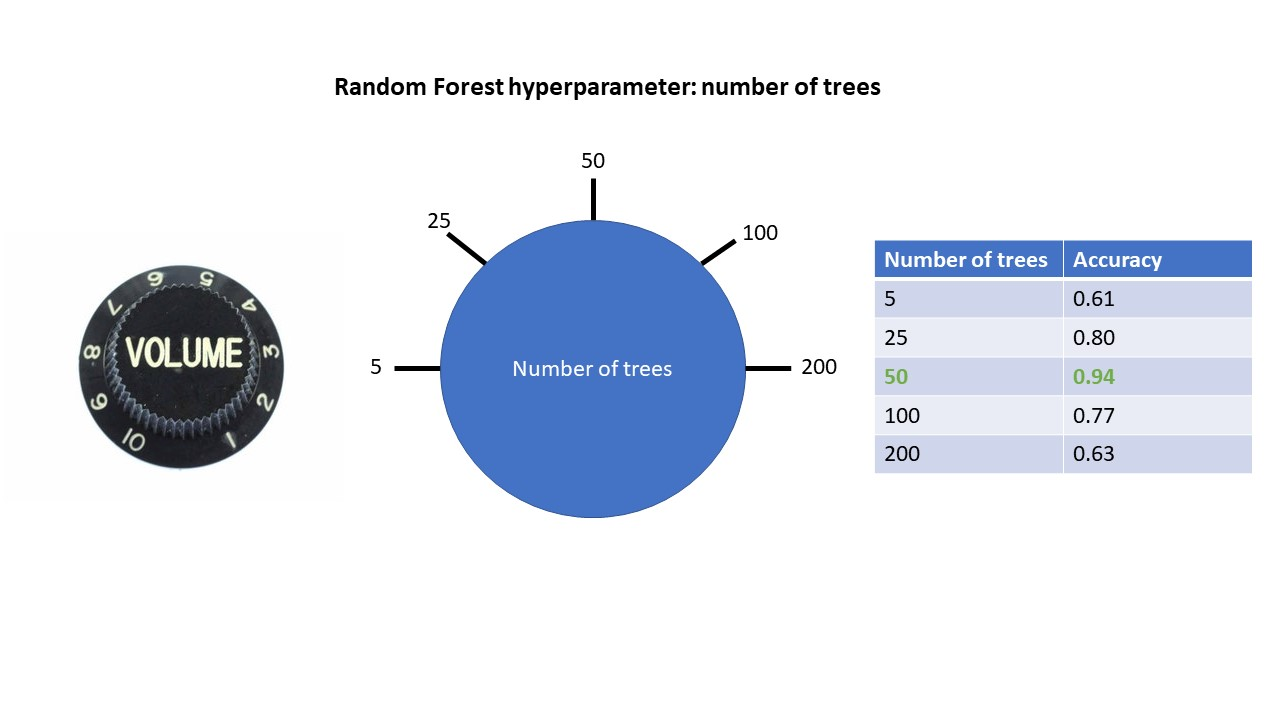

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 200%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >Data Splitting: Why?</p>
          
 **Fundamental Preliminary Concepts**
 
 1. In the real world your machine learning models will be predicting something **unknown** 
 2. We need to be sure our models perform reasonably well before using them in the real world
 3. The idea of splitting our data into training and testing sets is to mimic the real world
     - **Training data** is the "known" data used to train/develop a model
     - **Testing data** is the "unknown" data used to see if the model performs well on data it hasn't seen before
 4. However, we know the target values in the testing data, allowing us to see how well our models perform on "unseen" data before using them in the real world.
 
 **Note:** generally you only want to evaluate your models on the test set ONCE to avoid overfitting to the test data.
 
 **An Analogy: Human Learning versus Machine Learning** 
 
 1. Student = model. Study materials = training data. Exams = test data.
 2. Students prepare for exams using study materials that contain problems where the answers are known. This is similar to the training data for our machine learning models. In both cases the student and model use the training data to learn a particular concept. 
 3. For a student the aim is to understand and learn the study materials so that they can score well on unknown problems in an exam. For machine learning models the aim is to understand and "learn" the training data so they can make accurate predictions on unseen real-world data.
 

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 200%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >Cross-validation (CV)
          
**Assume we have a training data set and a testing data set...**

- We generally only want to use the test set ONCE: after we have selected our final models. 
- But we want to apply the principle of evaluating our candidate models on unseen data using only the training set. How can we do that? By splitting the training data!

**What is cross validation? An example of 5-fold CV:**

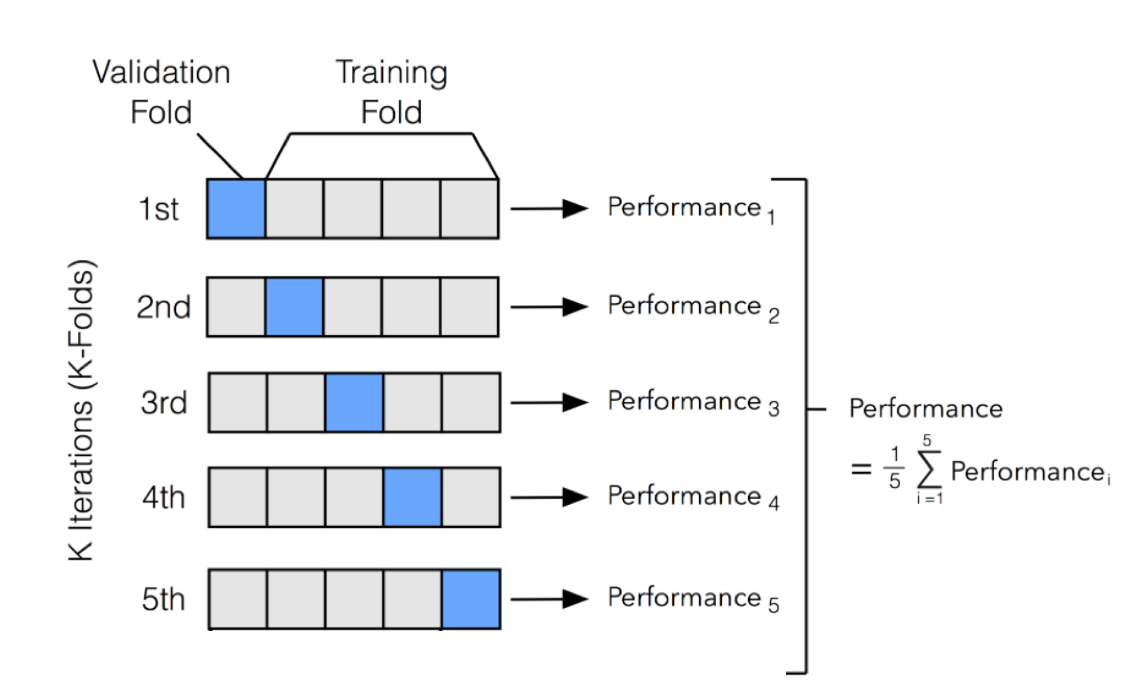

**What do we use cross-validation for?**

1. To determine which hyperparameters to use for each model
2. To determine which model will be our "final model"

**Why do K-fold CV?**

1. If you simply split the training data into two parts you may over or underestimate the performance of your model (the split may be a lucky or unlucky split)
2. Making multiple splits allows us to be more confident that the model performance is near what we estimate it to be
3. Some advanced approaches to ensure (2) is to do repeated cross-validation, such as repeating 10-fold CV 10 times

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 200%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >Model Development Pipeline</p>
          
**Disclaimer:** there are MANY different approaches for developing and evaluating machine learning models. The "best approach" is a highly debated topic, and may depend on your data and machine learning task. 

<div style="font-family:monospace; 
            border-radius:10px; 
            border:#f77f00 solid; 
            padding: 20px; 
            background-color: #caf0f8; 
            font-size:100%; 
            text-align: left">

<h1 align="left"><font color='#000000'>Example Project: Diabetes Classification</font></h1>

   The example project in this tutorial will be a classification task. The aim will be to predict (classify) individuals as having or not having diabetes based on other health data. The pipeline steps will be as follows:
 
 1. Read in and split the complete data into training and testing sets
 2. Select several candidate models 
 3. Perform cross-validation on the training data for every model
 4. Determine which models performed best on the training data set
 5. Select your "final model(s)"
 6. Make predictions on the test set
 7. Assess and visualize the results

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 200%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >Necessary Imports</p>

In [1]:
# Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Models
from sklearn.ensemble import RandomForestClassifier  # Random forest classifier

# Test train split
from sklearn.model_selection import train_test_split # Used to split the data intro training and testing sets
from sklearn.model_selection import cross_val_score  # Used to get cros-validation scores

# Evaluation metrics
from sklearn.metrics import accuracy_score            # Performance metric: accuracy
from sklearn.metrics import confusion_matrix          # Confusion matrix

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 200%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >Reference Code</p>

| Operations | Code | Notes |
| :--- | :--- | :--- | 
|Dropping a column from a data set (Pandas)|```df.drop('colname', axis=1)```|
|Selecting a single column (Pandas)|```df.loc[:,'colname']```|
|Splitting your data|```X_train, X_test, y_train, y_test``` <br><br> ```= train_test_split(X, y, random_state = 50)```|Where ```X``` is your feature matrix and ```y``` is your target.|
|Creating a random forest (classifier) |```rf = RandomForestClassifier(n_estimators = 100, random_state = 0)```|
|Getting average cross-validated accuracy scores|```cross_val_score(model_name, X_train, y_train, cv=10, scoring='accuracy')```|cv = number of folds for cross validation|
|Fitting (training) a model|```model_name.fit(X = X_train, y = y_train)```|For the random forest model defined above we would use ```rf.fit()``` |
|Making predictions|```model_preds = model_name.predict(X = X_test)```|Often we need to save our predictions, ie ```model_preds = ....```|
|Getting the accuracy of our model|```accuracy_score(y_true = target, y_pred = model_preds)```|

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 150%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >(1) Read in and split the data </p>

<div style="font-family:monospace; 
            border-radius:10px; 
            border:#A8A8A8 solid; 
            padding: 15px; 
            background-color: #caf0f8; 
            font-size:100%; 
            text-align:left">

<h3 align="left"><font color='#000000'>🖊 Extra Notes:</font></h3>

* The outcome variable is ```Diabetes``` which is ```1``` if someone has diabetes and ```0``` if they do not.
 
* All other variables in the data can be used for prediction

In [2]:
# Now lets read in the diabetes data 
df = pd.read_csv('diabetes-data.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
0,6,148,72,35,200,33.6,0.627,50,1
1,1,85,66,29,62,26.6,0.351,31,0
2,8,183,64,32,238,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Define feature matrix (X) and target vector (y)
X = df.drop('Diabetes', axis=1) # Feature matrix
y = df.loc[:,'Diabetes']        # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 150%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >(2) Select candidate models </p>

<div style="font-family:monospace; 
            border-radius:10px; 
            border:#A8A8A8 solid; 
            padding: 15px; 
            background-color: #caf0f8; 
            font-size:100%; 
            text-align:left">

<h3 align="left"><font color='#000000'>🖊 IMPORTANT for the course project:</font></h3>

In your course project you will need to use 3 different model types! Do not just create multiple random forest models, instead, select models with different underlying algorithms.

In [4]:
# Define random forest models with different hyperparameters
rf1 = RandomForestClassifier(n_estimators=2, random_state=0)
rf2 = RandomForestClassifier(n_estimators=10, random_state=0)
rf3 = RandomForestClassifier(n_estimators=150, random_state=0)
rf4 = RandomForestClassifier(n_estimators=1500, random_state=0)

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 150%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >(3) Perform 5-fold cross-validation on the training data </p>

In [5]:
# Perform 5-fold CV on the training data 
rf1_cv_acc = cross_val_score(rf1, X_train, y_train, cv=5, scoring='accuracy') # cv = 5 incdicates 5-fold cross validation
rf2_cv_acc = cross_val_score(rf2, X_train, y_train, cv=5, scoring='accuracy')
rf3_cv_acc = cross_val_score(rf3, X_train, y_train, cv=5, scoring='accuracy')
rf4_cv_acc = cross_val_score(rf4, X_train, y_train, cv=5, scoring='accuracy')

print(f'rf1 accuracy scores: {rf1_cv_acc}') # Get the accuracy scores from each fold
print(f'rf2 accuracy scores: {rf2_cv_acc}') # Get the accuracy scores from each fold
print(f'rf3 accuracy scores: {rf3_cv_acc}') # Get the accuracy scores from each fold
print(f'rf4 accuracy scores: {rf4_cv_acc}') # Get the accuracy scores from each fold

rf1 accuracy scores: [0.67241379 0.73043478 0.69565217 0.65217391 0.74782609]
rf2 accuracy scores: [0.71551724 0.77391304 0.7826087  0.69565217 0.74782609]
rf3 accuracy scores: [0.73275862 0.77391304 0.79130435 0.69565217 0.7826087 ]
rf4 accuracy scores: [0.71551724 0.7826087  0.76521739 0.68695652 0.79130435]


<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 150%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >(4) Determine which model performed best during 5-fold CV </p>

<div style="font-family:monospace; 
            border-radius:10px; 
            border:#A8A8A8 solid; 
            padding: 15px; 
            background-color: #caf0f8; 
            font-size:100%; 
            text-align:left">

<h3 align="left"><font color='#000000'>🖊 How to select the best model</font></h3>

We take the average accuracy across all folds for each model and select the one with the highest average accuracy. 

In [6]:
# Get average accuracy across all CV folds
print(f'Average 5-fold cross-validation accuracy for rf1 (n_estimators = 2): {rf1_cv_acc.mean()}')
print(f'Average 5-fold cross-validation accuracy for rf2 (n_estimators = 10): {rf2_cv_acc.mean()}')
print(f'Average 5-fold cross-validation accuracy for rf3 (n_estimators = 150): {rf3_cv_acc.mean()}')
print(f'Average 5-fold cross-validation accuracy for rf4 (n_estimators = 1500): {rf4_cv_acc.mean()}')

Average 5-fold cross-validation accuracy for rf1 (n_estimators = 2): 0.6997001499250375
Average 5-fold cross-validation accuracy for rf2 (n_estimators = 10): 0.743103448275862
Average 5-fold cross-validation accuracy for rf3 (n_estimators = 150): 0.755247376311844
Average 5-fold cross-validation accuracy for rf4 (n_estimators = 1500): 0.7483208395802099


<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 150%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >(5) Select final model(s) </p>

<div style="font-family:monospace; 
            border-radius:10px; 
            border:#A8A8A8 solid; 
            padding: 15px; 
            background-color: #caf0f8; 
            font-size:100%; 
            text-align:left">

<h3 align="left"><font color='#000000'>🖊 Extra Notes</font></h3>

* Once we select the best model and hyperparameter configuration we need to fit the model to the **entire training data** before making predictions on the test set.
    
* Note that **for the course project you will need to select 3 models**

In [7]:
# Fit best Random Forest to the entire training data
rf_final_model = RandomForestClassifier(n_estimators=150, random_state=0)
rf_final_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150, random_state=0)

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 150%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >(6) Make predictions on the test set </p>

In [8]:
# Make predictions on the training and test set
train_preds = rf_final_model.predict(X_train)
test_preds = rf_final_model.predict(X_test)

<p style="font-family: monospace; 
          font-weight: bold; 
          letter-spacing: 1px; 
          color: black; 
          font-size: 150%; 
          text-align: left;
          padding: 8px; 
          border-bottom: 3px solid #4cc9f0" >(7) Assess and visualize results </p>

In [9]:
# Calculate the accuracy for each
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, test_preds)

# Print
print(f'Training set accuracy: {train_accuracy}')
print(f'Test set accuracy: {test_accuracy}')

Training set accuracy: 1.0
Test set accuracy: 0.78125


Training set confusion matrix:


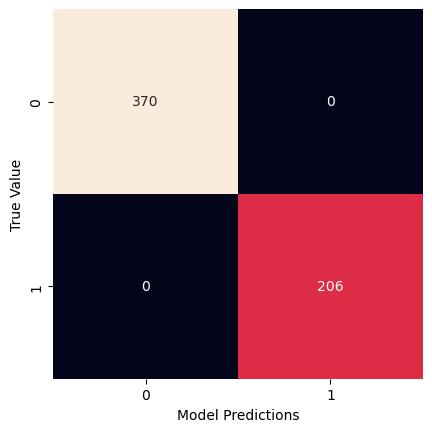

In [10]:
# Training set confusion matric
print('Training set confusion matrix:')
conf_matrix = confusion_matrix(y_train, train_preds)
sns.heatmap(conf_matrix, square=True, annot=True, cbar=False, fmt='g')
plt.xlabel('Model Predictions')
plt.ylabel('True Value');

Test set confusion matrix:


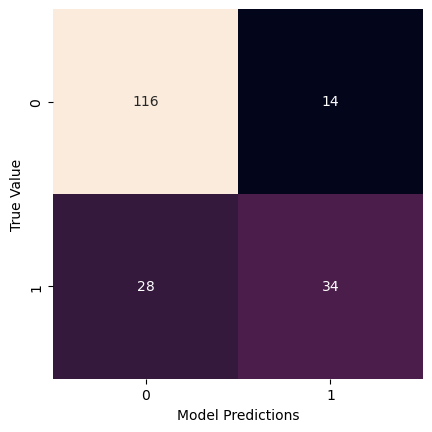

In [11]:
# Test set confusion matrix
print('Test set confusion matrix:')
conf_matrix = confusion_matrix(y_test, test_preds)
sns.heatmap(conf_matrix, square=True, annot=True, cbar=False, fmt='g')
plt.xlabel('Model Predictions')
plt.ylabel('True Value');

<div style="font-family:monospace; 
            border-radius:10px; 
            border:#A8A8A8 solid; 
            padding: 15px; 
            background-color: #caf0f8; 
            font-size:100%; 
            text-align:left">

<h3 align="left"><font color='#000000'>🖊 Extra notes</font></h3>

You may wish to also look at sensitivity, specificity, or other metrics that can be gathered from a confusion matrix in order to evaluate your model. 